# Student Success Factors Dashboard — Exploratory Data Analysis

## Objective
This notebook explores behavioral and academic trends among Software Engineering students.

### Analysis Goals
- Understand GPA patterns
- Identify factors affecting academic performance
- Explore attendance and study behavior
- Analyze student challenges
- Generate actionable insights


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load cleaned dataset
df = pd.read_csv('../data/processed/clean_survey_responses.csv')

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,submission_timestamp,anonymous_id,department,year_of_study,current_semester,highest_scoring_course_code,highest_grade,lowest_scoring_course_code,lowest_grade,attendance_percent,study_hours_week,attends_tutorial,assignment_completion_rate,gpa,course_difficulty,main_challenge,study_group,online_resources,success_factor,preferred_study_time,failed_course_before,laptop_access,internet_quality,lives_in_dorm,part_time_job,sleep_hours_night,mental_health_rating,academic_risk,engagement_score
0,2025-11-03 08:14:22,panda12,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A-,Math2201,C,88.0,12,Yes,95,3.21,3,Time management,Yes,Yes regularly,Study groups and past exams help me most,Evening,No,Yes,Good,Yes,No,7,4,Low Risk,97.2
1,2025-11-03 08:33:11,ninja07,Software Engineering,Year 3,2025/2026 First Semester,SEng3201,B+,Math2201,C-,74.0,8,No,79,2.71,4,Programming difficulty,No,Sometimes,Watching YouTube tutorials when stuck,Night,Yes,Yes,Fair,No,No,6,3,Moderate Risk,77.2
2,2025-11-03 08:55:40,bytecoder,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A,CSEg3204,B-,93.0,16,Yes,98,3.82,2,None really,Yes,Yes regularly,Consistent revision and coding practice,Morning,No,Yes,Good,No,No,8,5,Low Risk,108.4
3,2025-11-03 09:10:18,starlite,Software Engineering,Year 3,2025/2026 First Semester,SEng3201,B,Math2201,D+,62.0,5,No,68,2.14,5,Lack of resources,No,Never,Trying to survive exams only,Afternoon,Yes,No,Poor,Yes,Yes,5,2,High Risk,62.0
4,2025-11-03 09:31:56,codewave,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A,Math2201,B,96.0,20,Yes,100,3.94,2,NaN,Yes,Yes regularly,Discipline and active practice,Morning,No,Yes,Good,No,No,7,5,Low Risk,118.4


## Dataset Overview

### Business Objective
Understand the structure and size of the cleaned academic survey dataset.


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.info()

Dataset Shape: (30, 29)

Columns:
['submission_timestamp', 'anonymous_id', 'department', 'year_of_study', 'current_semester', 'highest_scoring_course_code', 'highest_grade', 'lowest_scoring_course_code', 'lowest_grade', 'attendance_percent', 'study_hours_week', 'attends_tutorial', 'assignment_completion_rate', 'gpa', 'course_difficulty', 'main_challenge', 'study_group', 'online_resources', 'success_factor', 'preferred_study_time', 'failed_course_before', 'laptop_access', 'internet_quality', 'lives_in_dorm', 'part_time_job', 'sleep_hours_night', 'mental_health_rating', 'academic_risk', 'engagement_score']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   submission_timestamp         30 non-null     object 
 1   anonymous_id                 30 non-null     object 
 2   department                   30 non-null     obj

The cleaned dataset contains 30 student records and 29 variables covering academic performance, study behavior, engagement, and lifestyle-related factors.

## GPA Distribution

Understand how students are performing academically overall.


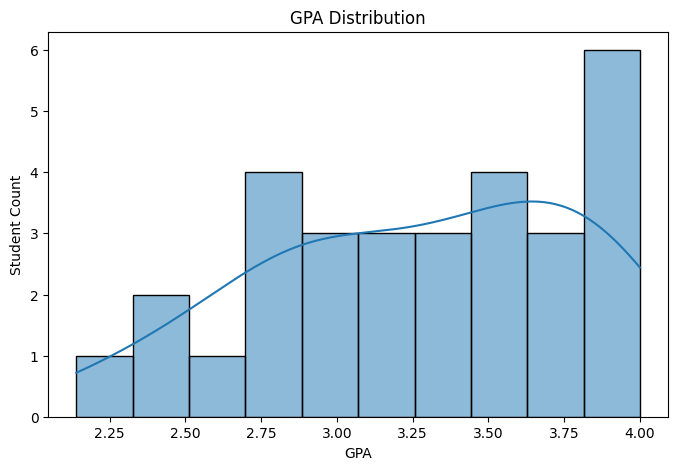

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['gpa'], bins=10, kde=True)

plt.title('GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Student Count')

plt.show()

Interpretation

Most students fall within the mid-to-high GPA range, while a smaller group shows lower academic performance levels.

Recommendation

Additional academic support should focus on students within the lower GPA range to improve overall performance consistency.

## Attendance vs GPA

Determine whether class attendance impacts academic performance.


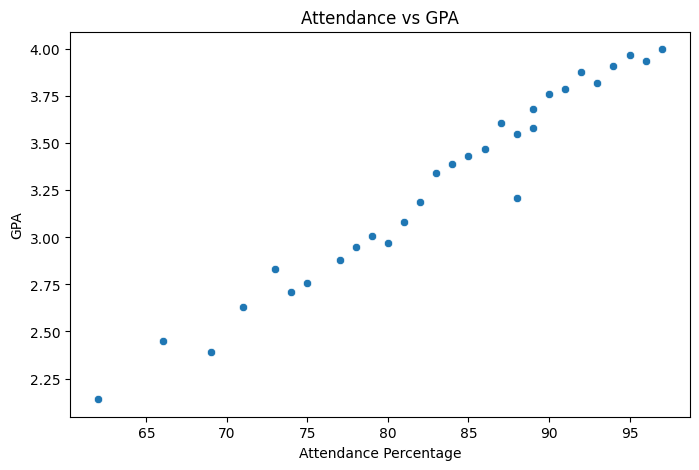

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='attendance_percent',
    y='gpa'
)

plt.title('Attendance vs GPA')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')

plt.show()

### Technical Interpretation

The scatterplot visualizes the relationship between attendance and GPA.

###  Interpretation

Students with higher attendance generally appear to achieve better academic outcomes.

### Recommendation

Encourage consistent attendance through:
- attendance monitoring,
- participation incentives,
- and academic support programs.


## Study Hours vs GPA

### Business Objective
Analyze whether study time contributes to higher GPA.


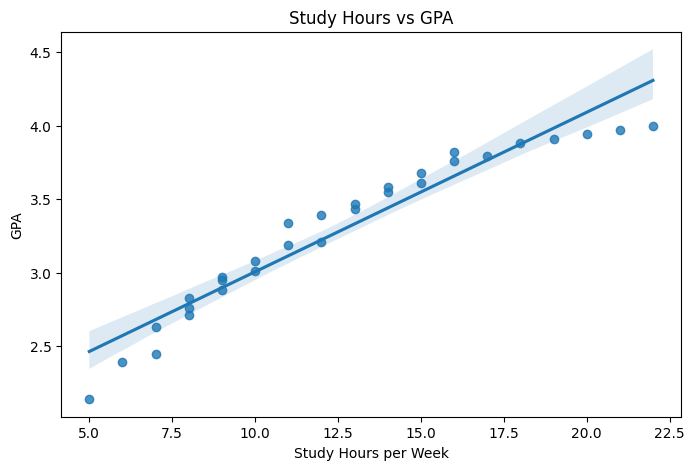

In [7]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x='study_hours_week',
    y='gpa'
)

plt.title('Study Hours vs GPA')
plt.xlabel('Study Hours per Week')
plt.ylabel('GPA')

plt.show()

### Technical Interpretation

The regression plot highlights the trend between study hours and GPA.

### Business Interpretation

Students who dedicate more time to studying tend to achieve stronger academic performance.

### Recommendation

Universities can promote:
- time management workshops,
- study planning strategies,
- and peer accountability systems.


## Course Difficulty Distribution



Understand how students perceive course difficulty.


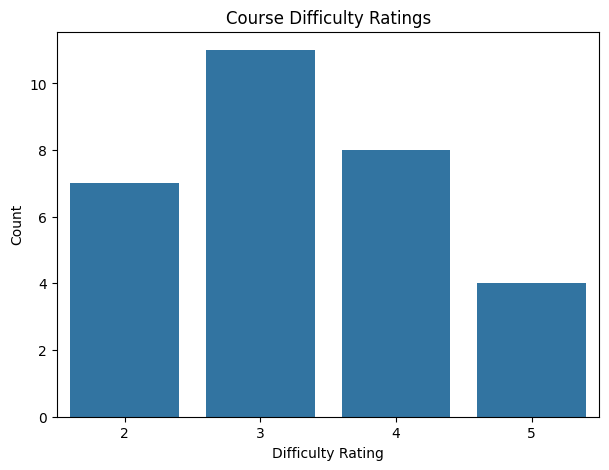

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='course_difficulty')

plt.title('Course Difficulty Ratings')
plt.xlabel('Difficulty Rating')
plt.ylabel('Count')

plt.show()

### Technical Interpretation

Most students rated courses between moderate and difficult.

### Business Interpretation

Certain technical courses may require additional academic support resources.

### Recommendation

Provide:
- tutorial sessions,
- mentorship,
- and supplementary learning materials.


## Main Academic Challenges

### Business Objective
Identify the most common student obstacles.


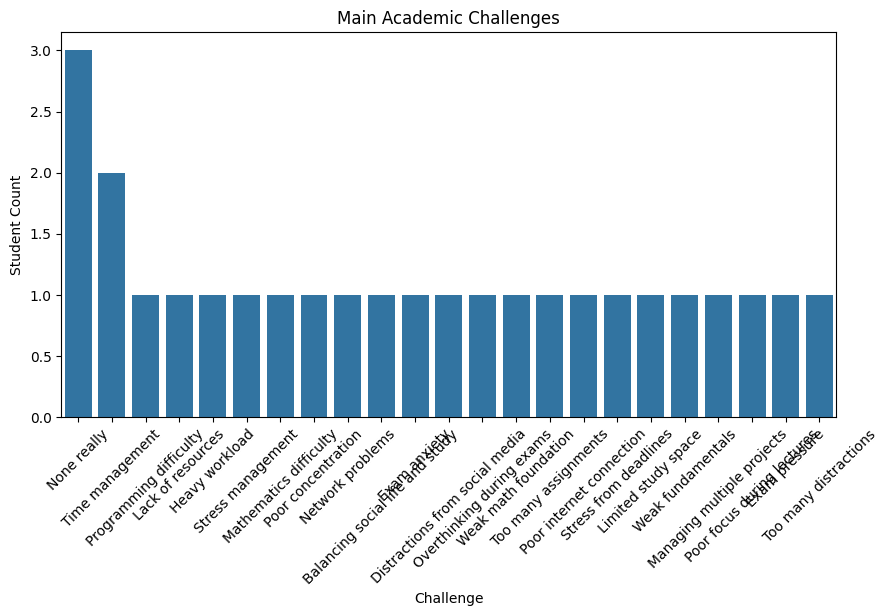

In [9]:
challenge_counts = df['main_challenge'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(
    x=challenge_counts.index,
    y=challenge_counts.values
)

plt.xticks(rotation=45)
plt.title('Main Academic Challenges')
plt.xlabel('Challenge')
plt.ylabel('Student Count')

plt.show()

### Technical Interpretation

The chart summarizes recurring academic challenges reported by students.


Common challenges may indicate systemic issues affecting student performance.

### Recommendation

The department can develop targeted support initiatives based on the most frequent student difficulties.


## Preferred Study Time

### Business Objective
Understand when students prefer studying.


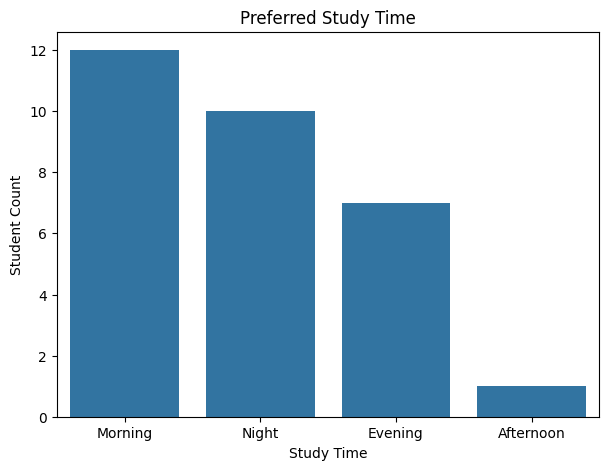

In [10]:
study_time_counts = df['preferred_study_time'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(
    x=study_time_counts.index,
    y=study_time_counts.values
)

plt.title('Preferred Study Time')
plt.xlabel('Study Time')
plt.ylabel('Student Count')

plt.show()

Interpretation

Students demonstrate different study-time preferences, with many preferring morning and evening study sessions.

Recommendation

Students should study during the time periods where they feel most focused and productive.

## Mental Health Rating vs GPA

Analyze whether mental health relates to academic performance.


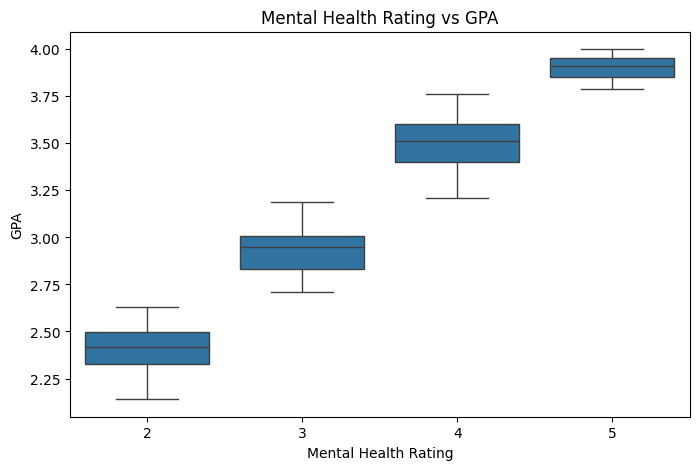

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='mental_health_rating',
    y='gpa'
)

plt.title('Mental Health Rating vs GPA')
plt.xlabel('Mental Health Rating')
plt.ylabel('GPA')

plt.show()



### Business Interpretation

Students with stronger mental well-being may demonstrate more stable academic performance.

### Recommendation

Universities should consider strengthening:
- counseling services,
- stress management programs,
- and mental health awareness initiatives.


## Academic Risk Distribution

### Business Objective
Understand how many students fall into different academic risk categories.


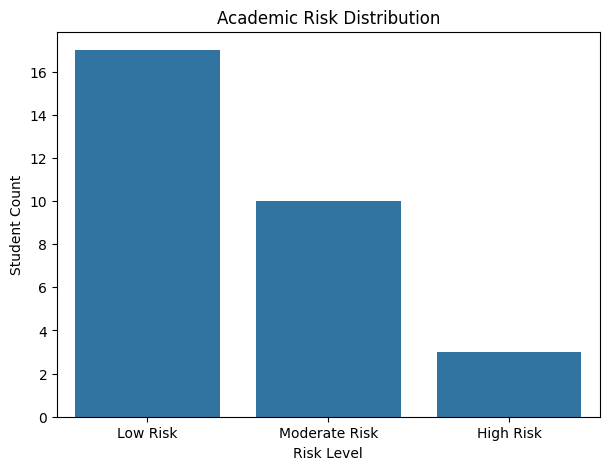

In [12]:
risk_counts = df['academic_risk'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title('Academic Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Student Count')

plt.show()

### Technical Interpretation

Students are grouped into:
- Low Risk
- Moderate Risk
- High Risk

based on GPA thresholds.

### Business Interpretation

Risk segmentation allows departments to identify vulnerable students earlier.


## Correlation Heatmap

### Business Objective
Identify variables most associated with GPA.


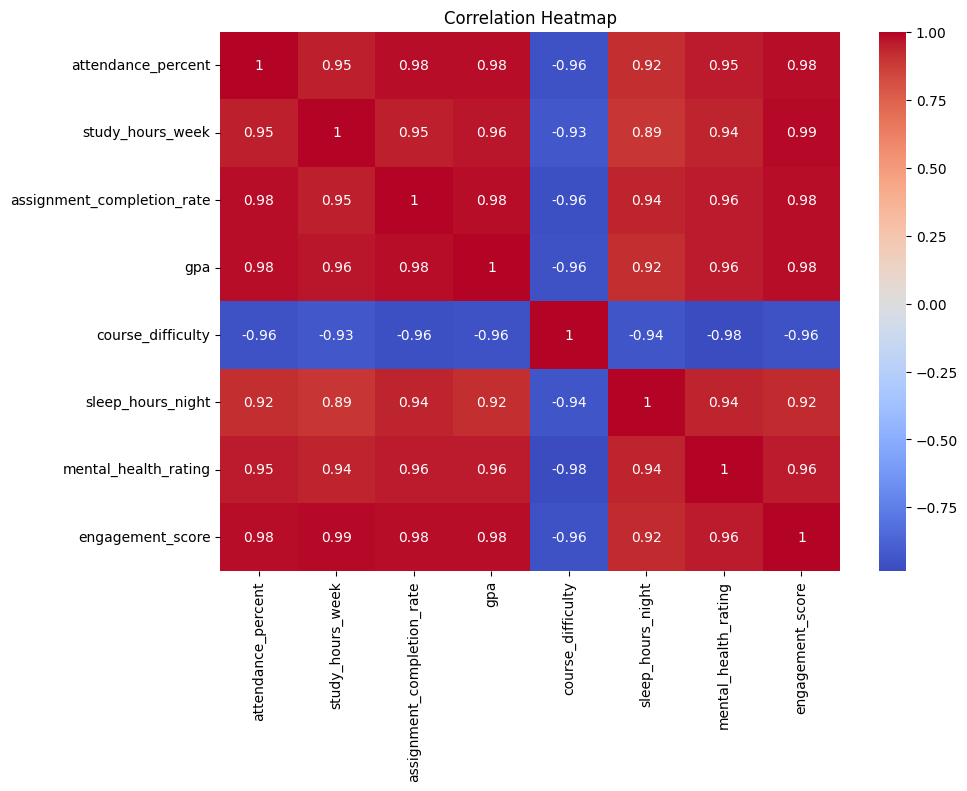

In [13]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Technical Interpretation

The heatmap measures linear relationships between numerical variables.

### Interpretation

Variables such as attendance, study hours, assignment completion, and engagement score appear positively associated with GPA

### Recommendation

Students should improve daily academic habits consistently rather than focusing only on exam performance.


## Top Performing Students

### Business Objective
Identify high-performing students for benchmarking.


In [14]:
top_students = df.sort_values(by='gpa', ascending=False)[
    ['anonymous_id', 'gpa', 'study_hours_week', 'attendance_percent']
].head(10)

top_students

,anonymous_id,gpa,study_hours_week,attendance_percent
14,devlegend,4.00,22,97.0
28,datastream,3.97,21,95.0
4,codewave,3.94,20,96.0
25,smartloop,3.91,19,94.0
22,bughunter,3.88,18,92.0
2,bytecoder,3.82,16,93.0
11,alphaByte,3.79,17,91.0
16,neuralAce,3.76,16,90.0
27,compileX,3.68,15,89.0
13,binarymind,3.61,15,87.0


Interpretation

Top-performing students consistently maintain high attendance, stronger study habits, and higher engagement levels.

Recommendation

Students aiming to improve academically should model the study behaviors and consistency patterns of top-performing peers.


EDA Summary
Interpretation

The analysis indicates that academic success is strongly connected to consistency, engagement, study discipline, and healthy academic habits.

Recommendation

Students should combine effective study habits, active participation, and personal well-being practices to improve long-term academic performance.